<div align = "justify">

<p align="center">
  <img src="https://www.uao.edu.co/wp-content/uploads/2024/12/UAO-LOGO-NUEVO_Mesa-de-trabajo-1-1-1-1.png" width="350">
</p>

# **Prediction of Hourly $PM_{2.5}$ Concentrations Using Machine Learning Techniques in Bucaramanga, Colombia**  
---

## **Final Project – Machine Learning Applied to Air Quality**
  
**Program:** Specialization in Artificial Intelligence  
**Institution:** Universidad Autónoma de Occidente (UAO)  
**Semester:** 2025–2S  

---

## **Authors**
- Jorman Alexis Munoz Anacona - 2190382
- Saulo Quiñones Góngora - 22506635
- Adrian Felipe Vargas Rojas - 22505561
- Luis David Hurtado Caicedo - 22507571
- Manuel Castillo Rosales - 22506986

---
## **Instructor**

**Juan Camilo Giraldo Londoño**

*Course: Machine Learning*

---

</div>

<div align = "justify">

#**Introduction**

The concentration of fine particulate matter $PM_{2.5}$ is a critical indicator of air quality due to its direct impact on human health and environmental well-being. In cities like Bucaramanga, the hourly variability of $PM_{2.5}$ is strongly influenced by meteorological factors and urban dynamics, which makes the development of predictive tools that can anticipate episodes of air quality deterioration especially relevant.

This notebook develops the technical process required to build a machine learning model capable of predicting the future concentration of $PM_{2.5}$ one hour ahead (t+1) based on historical pollution records and meteorological variables. To this end, the following stages are carried out: data preparation, generation of temporal features, training and validation of supervised models, and comparative evaluation against a baseline model. The purpose of this notebook is to document the computational workflow associated with the project, ensuring reproducibility and providing support for the results presented in the final article.

</div>

# **1. Library Installation**

In [ ]:
!pip install sodapy

'''
Sodapy is a Python library for interacting with the Socrata Open Data API.
Through Sodapy, it is possible to access, retrieve, and process data published by governments and organizations on Socrata platforms.
'''

'\nSodapy es una biblioteca de Python para interactuar con la API de Datos Abiertos de Socrata (Socrata Open Data API).\nPor medio de Sodapy, se puede acceder, recuperar y procesar datos publicados por gobiernos y organizaciones en plataformas Socrata.\n'

In [ ]:
import pandas as pd               # Handling, cleaning, and structuring of tabular data.
import time                       # Measuring execution time and basic time-related functions.
from sodapy import Socrata        # Access to open data via the Socrata Open Data API.
import matplotlib.pyplot as plt   # Generation of basic charts and static visualizations.
import numpy as np                # Efficient numerical operations with arrays and mathematical functions.
from sklearn.linear_model import Ridge                   # Ridge-type regularized linear regression model.
from sklearn.ensemble import AdaBoostRegressor           # Boosting-based ensemble algorithm for regression.
from sklearn.tree import DecisionTreeRegressor           # Decision tree for regression tasks.
from sklearn.ensemble import RandomForestRegressor       # Ensemble model based on multiple decision trees.
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV  # Time series cross-validation and hyperparameter search.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics for regression.
from matplotlib.ticker import FuncFormatter, MaxNLocator # Axis formatting and control of tick count in plots.
import matplotlib.patches as mpatches                    # Creation of custom graphical elements (legends, patches).
import re                                                # Regular expressions for text handling and cleaning.
import seaborn as sns                                    # Statistical visualization library with high-level plots.
import joblib

# **2. Data Extraction**

<div align = "justify">

In this section, hourly air quality records were extracted directly from the Colombia Open Data platform using the Socrata API. The retrieved data includes pollution and meteorological variables, and is converted into a pandas DataFrame for subsequent analysis and preprocessing.

</div>

In [ ]:
client = Socrata("www.datos.gov.co", None)

results = client.get("58ct-h586", limit=16825)

# Convert to pandas DataFrame
df = pd.DataFrame.from_records(results)

In [ ]:
df

,tiempo,est_lagos_i_f_blanca_pm10,est_lagos_i_f_blanca_pm2,est_lagos_i_f_blanca_no2,est_lagos_i_f_blanca_o3,est_laciudadela_pm10,est_laciudadela_pm2_5,est_laciudadela_no2,est_laciudadela_o3,est_santa_cruz_gir_n_pm10,...,est_san_francisco_humedad,est_san_francisco_dir_viento,est_san_francisco_vel_viento,est_san_francisco_rad_solar,est_lagos_del_cacique,est_lagos_del_cacique_lluvia,est_lagos_del_cacique_humedad,est_lagos_del_cacique_dir,est_lagos_del_cacique_vel,est_lagos_del_cacique_rad
0,01/10/2018 00:00,NA,NA,NA,NA,23.8,12.1,23.8128,3.4,13.5,...,80.2,126.2,1,0,22.2,0.1,83.5,290.6,NA,0
1,01/10/2018 01:00,NA,NA,NA,NA,14.6,7.5,1.2628,17.5,12.7,...,88,124.6,1.1,0,21.7,0,89.8,109.9,NA,0
2,01/10/2018 02:00,NA,NA,NA,NA,14.5,7.7,12.628,7.2,16.2,...,87,134.8,1.1,0,21.7,0,86.8,350.4,NA,0
3,01/10/2018 03:00,NA,NA,NA,NA,16.6,7.9,13.3496,NA,16.3,...,83.1,140.6,0.8,0,21.6,0,84.9,258.3,NA,0
4,01/10/2018 04:00,NA,NA,NA,NA,18.3,9.5,8.4788,3.6,15.1,...,90.8,177.5,1,0,20.7,0,91.7,170.6,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16819,31/08/2020 19:00,NA,NA,NA,NA,40.2,23.2,37.1624,NA,60.8,...,77.2,NA,NA,0,41.5,0,77,319.4,0.1,0
16820,31/08/2020 20:00,NA,NA,NA,NA,47.1,25.4,24.5344,NA,62.3,...,77.8,NA,NA,0,50.2,0,78.7,66.3,0.2,0
16821,31/08/2020 21:00,NA,NA,NA,NA,40.5,22.9,27.6012,NA,58.7,...,77,NA,NA,0,44.4,0,79.8,218.9,0,0
16822,31/08/2020 22:00,NA,NA,NA,NA,41.4,23.5,25.0756,NA,54.8,...,74.9,NA,NA,0,36.6,0,81.3,162.9,0.2,0


# **3. Exploratory Data Analysis**

## **Identification of Null Values**

<div align = "justify">

As part of the exploratory data analysis, an initial cleaning of the dataset was carried out with the goal of standardizing null or empty values and verifying the overall structure of the DataFrame.

First, different representations of missing values (`"NA"`, `"N/A"`, `"na"`, `"-"`, blank spaces, etc.) were replaced with pandas' standard null value (`pd.NA`), in order to facilitate their counting and subsequent handling.

</div>

In [ ]:
df = df.replace(["NA", "N/A", "na", "--", " ", ""], pd.NA)

<div align = "justify">

Next, `df.info()` was used to obtain an overview of the dataset:
   - Total number of records and columns.  
   - Number of non-null values per variable.  
   - Data type of each column, which makes it possible to identify those requiring conversion to numeric or datetime format (for example, the `tiempo` column).

This step made it possible to diagnose the initial state of the dataset and plan the subsequent stages of the EDA (type conversion, completeness analysis, and generation of derived variables).

</div>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16824 entries, 0 to 16823
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tiempo                         16824 non-null  object
 1   est_lagos_i_f_blanca_pm10      10731 non-null  object
 2   est_lagos_i_f_blanca_pm2       13751 non-null  object
 3   est_lagos_i_f_blanca_no2       9719 non-null   object
 4   est_lagos_i_f_blanca_o3        9833 non-null   object
 5   est_laciudadela_pm10           12529 non-null  object
 6   est_laciudadela_pm2_5          13204 non-null  object
 7   est_laciudadela_no2            11815 non-null  object
 8   est_laciudadela_o3             13136 non-null  object
 9   est_santa_cruz_gir_n_pm10      14755 non-null  object
 10  est_santa_cruz_gir_n_pm2       16155 non-null  object
 11  est_san_francisco_pm10         15860 non-null  object
 12  est_san_francisco_pm2_5        15865 non-null  object
 13  e

<div align = "justify">

Using the `df.shape` command, it is possible to observe that the dataset contains 16824 records and 45 features.

</div>

In [ ]:
df.shape

(16824, 45)

In [ ]:
df.duplicated().sum()

np.int64(0)

## **Variable Name Normalization**

<div align = "justify">

Some stations report the concentration of fine particulate matter with different labels (`pm_2`, `pm2`, `PM2`, etc.), which creates inconsistencies when processing the dataset. For this reason, a regular expression was applied that unifies all variants into a standard format (`pm2_5`), ensuring consistency among the columns of the different stations. The result confirms that all names have been correctly normalized.

</div>

In [ ]:
def normalizar_pm25(nombre_col):
    # replace any pattern like 'pm2', 'pm_2', 'PM2', etc., that does not have the 5
    nuevo = re.sub(r"(?i)pm[_]?2(?!_?5)", "pm2_5", nombre_col)
    return nuevo

# Apply the function to each of the columns.
df.columns = [normalizar_pm25(c) for c in df.columns]

# Verification of the result
print("Columns after normalization:\n", [c for c in df.columns if "pm" in c.lower()])


Columnas después de normalizar:
 ['est_lagos_i_f_blanca_pm10', 'est_lagos_i_f_blanca_pm2_5', 'est_laciudadela_pm10', 'est_laciudadela_pm2_5', 'est_santa_cruz_gir_n_pm10', 'est_santa_cruz_gir_n_pm2_5', 'est_san_francisco_pm10', 'est_san_francisco_pm2_5', 'est_lagos_del_cacique_pm10', 'est_lagos_del_cacique_pm2_5']


<div align = "justify">

The time column and the $PM_{2.5}$ series were converted to formats suitable for analysis, and a monthly variable was generated from the time index. Subsequently, the monthly average of $PM_{2.5}$ was calculated and visualized to identify seasonal variations in pollutant concentration.


</div>

## **Variable Distribution by Station**

<div align = "justify">

With the purpose of assessing the quality and availability of the information from each monitoring station, the number of valid records (without null values) was calculated per variable and station. In the code cell described below, it was comparatively identified which stations present greater data coverage both for atmospheric pollutants (PM₁₀, PM₂.₅, NO₂, O₃) and for meteorological variables (wind direction and speed, humidity, radiation, and rainfall). This diagnosis is essential for selecting the stations with the best record completeness, ensuring the consistency and reliability of the subsequent predictive modeling.

</div>

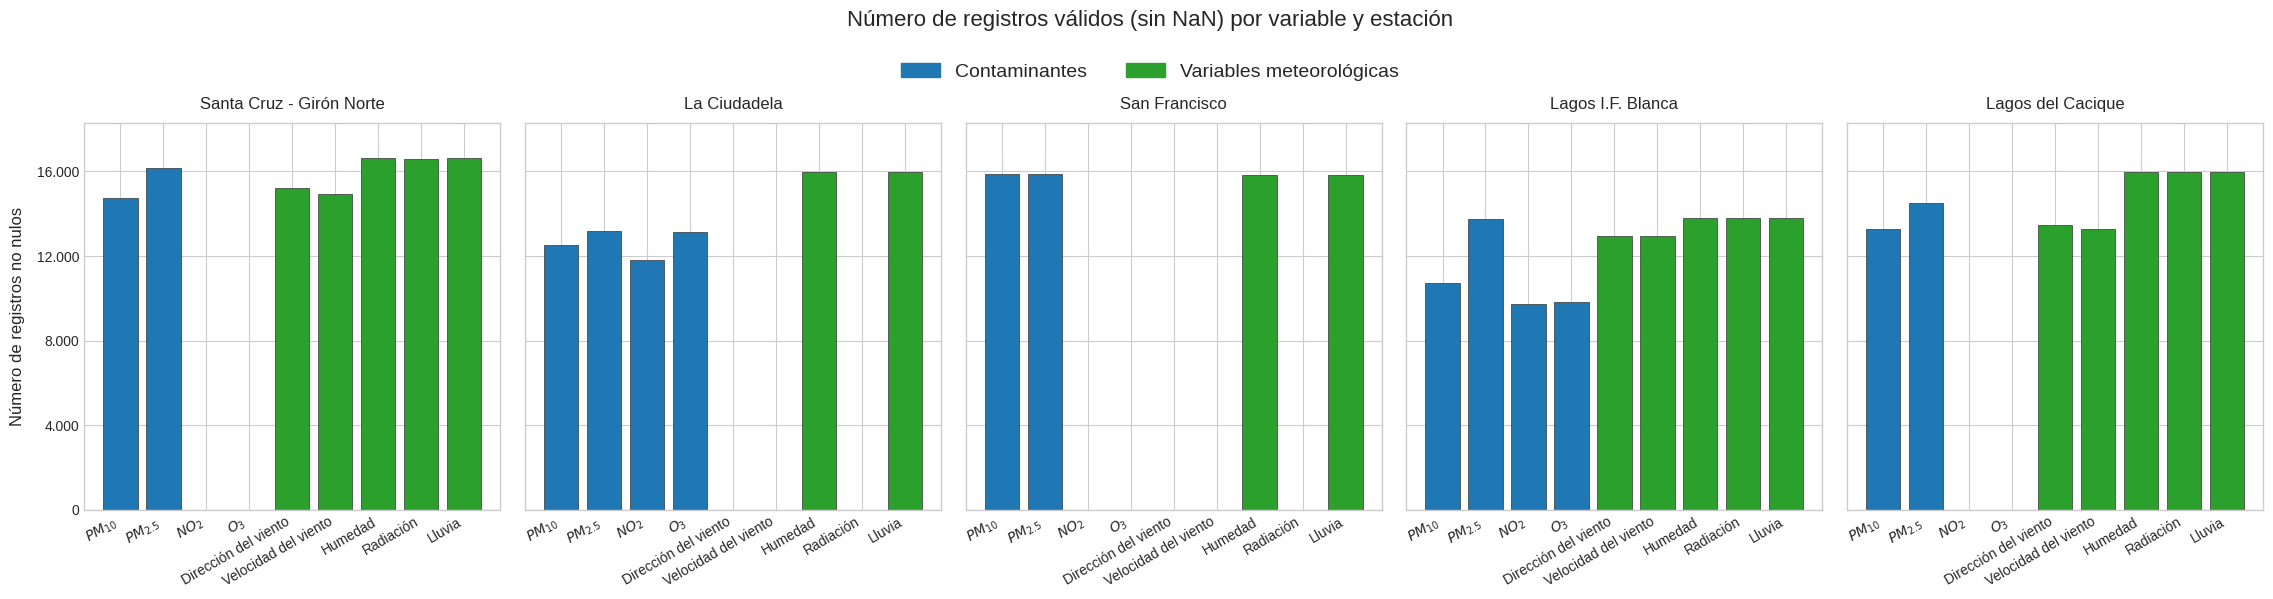

In [ ]:
#Distribution of variables by station
stations = ["santa_cruz_gir_n", "laciudadela", "san_francisco",
            "lagos_i_f_blanca", "lagos_del_cacique"]

estaciones = {
    "santa_cruz_gir_n": "Santa Cruz - Girón Norte",
    "laciudadela": "La Ciudadela",
    "san_francisco": "San Francisco",
    "lagos_i_f_blanca": "Lagos I.F. Blanca",
    "lagos_del_cacique": "Lagos del Cacique"
}

# Split variables into two broad groups (pollutants and meteorological variables)

pollutants = ["pm10", "pm2_5", "no2", "o3"]
meteorologicas = ["dir", "vel", "humedad", "rad", "lluvia"]

# Display label map

pretty = {
    "pm10":  r"$PM_{10}$",
    "pm2_5": r"$PM_{2.5}$",
    "no2":   r"$NO_{2}$",
    "o3":    r"$O_{3}$",
    "dir":   "Wind direction",
    "vel":   "Wind speed",
    "humedad": "Humidity",
    "rad":   "Radiation",
    "lluvia":"Rainfall",
}

# Color palette
color_poll = "#1f77b4"  # blue
color_met  = "#2ca02c"  # green

# -----------------------------
# COMPUTATION OF NON-NULL VALUES PER VARIABLE AND STATION
# -----------------------------
data_counts = {}

for st in stations:
    cols_station = [c for c in df.columns if f"est_{st}_" in c]
    summary = {}

    for var in pollutants + meteorologicas:
        cols_var = [c for c in cols_station if c.endswith("_" + var)]
        count_non_null = df[cols_var[0]].notna().sum() if cols_var else 0
        summary[var] = int(count_non_null)

    data_counts[st] = summary

df_counts = pd.DataFrame(data_counts).T

# -----------------------------
# SUBPLOT CHARTS (1 row x 5 columns)
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, len(stations), figsize=(24, 6), sharey=True)

def thousands(x, pos):

    return f"{int(x):,}".replace(",", ".")

for i, st in enumerate(stations):
    ax = axes[i]
    df_plot = df_counts.loc[st]

    contam = df_plot[df_plot.index.isin(pollutants)]
    met    = df_plot[df_plot.index.isin(meteorologicas)]

    x_keys  = list(contam.index) + list(met.index)
    y_vals  = list(contam.values) + list(met.values)
    colors  = [color_poll] * len(contam) + [color_met] * len(met)

    bars = ax.bar(range(len(x_keys)), y_vals, color=colors, edgecolor="#333", linewidth=0.5)

    x_labels = [pretty.get(k, k) for k in x_keys]
    ax.set_xticks(range(len(x_keys)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")

    # Title per station
    ax.set_title(estaciones.get(st, st.replace("_", " ").title()), fontsize=12, pad=10)

    # Y axis
    ax.yaxis.set_major_formatter(FuncFormatter(thousands))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

    # Small margin
    ax.margins(y=0.10)

# Global legend
pollutant_patch = mpatches.Patch(color=color_poll, label="Pollutants")
meteorological_patch = mpatches.Patch(color=color_met, label="Meteorological variables")
fig.legend(handles=[pollutant_patch, meteorological_patch],
           loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.95), fontsize = 14)

# Titles and layout
fig.suptitle("Number of valid records (without NaN) per variable and station", fontsize=16, y=1.01)
fig.text(0.025, 0.5, "Number of non-null records", va="center", rotation="vertical", fontsize=12)
fig.tight_layout(rect=[0.03, 0.02, 0.97, 0.95])

plt.savefig("Plot.png")
plt.show()

<div align = "justify">

Considering that the goal of this project is to predict the concentration of fine particulate matter $PM_{2.5}$ one hour into the future $(t + 1)$, the station with the largest number of particulate matter records and meteorological variable information is Santa Cruz - Girón Norte, making it the most appropriate choice for this project. It is important to mention that information on variables such as $NO_2$ or $O_3$ is not required, since the goal is not to calculate or predict the Air Quality Index, which further confirms that the best option remains Santa Cruz - Girón Norte. Additionally, the monthly average of $PM_{2.5}$ was calculated in order to identify patterns between the concentration data and the temporal variables.

</div>

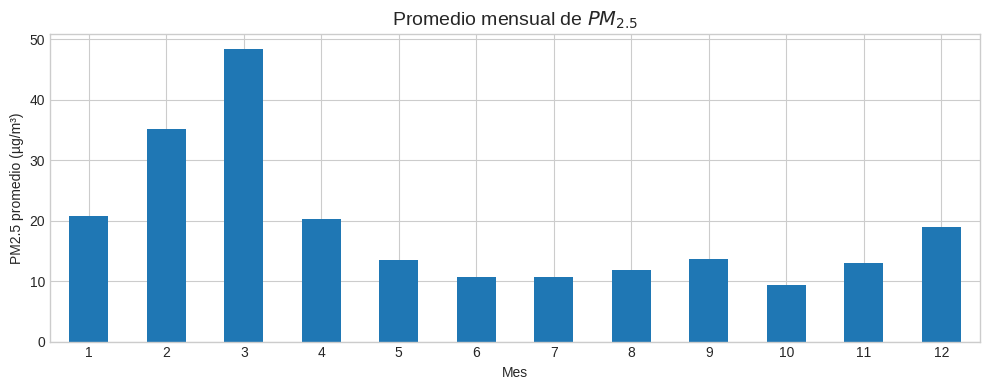

In [ ]:
# --- Monthly average PM2.5 ---

df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce', dayfirst=True)

df["est_santa_cruz_gir_n_pm2_5"] = pd.to_numeric(df["est_santa_cruz_gir_n_pm2_5"], errors='coerce')

df["month"] = df["tiempo"].dt.month

pm25_monthly = df.groupby("month")["est_santa_cruz_gir_n_pm2_5"].mean()

pm25_monthly.index = pm25_monthly.index.astype(int)

plt.figure(figsize=(10, 4))
pm25_monthly.plot(kind="bar")

plt.title("Monthly average $PM_{2.5}$", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Scatterplots and Box-and-Whisker Plots**

<div align = "justify">

This chart shows that during the first months of the year there is a significant increase in $PM_{2.5}$ concentrations. This behavior can be associated with several factors. On one hand, the climatic conditions typical of this period, such as higher humidity levels or lower wind speeds, can favor the accumulation of particulate matter and limit its dispersion. On the other hand, an increase in vehicle traffic or other emission sources characteristic of these months could also play a role. Taken together, these elements may help explain the observed behavior of $PM_{2.5}$ concentration at the beginning of the year.

</div>

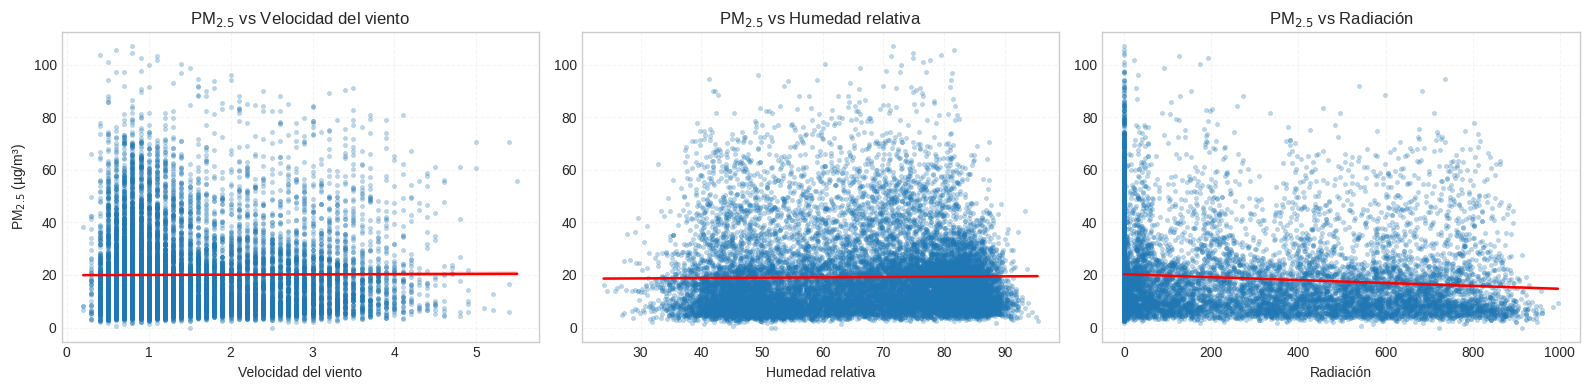

In [ ]:
# Scatterplots between PM2.5 and meteorological variables

variables_meteo = [
    "est_santa_cruz_gir_n_vel",
    "est_santa_cruz_gir_n_humedad",
    "est_santa_cruz_gir_n_rad"
]

# Readable names for the axes
nombre_vars = {
    "est_santa_cruz_gir_n_vel": "Wind speed",
    "est_santa_cruz_gir_n_humedad": "Relative humidity",
    "est_santa_cruz_gir_n_rad": "Radiation"
}

for col in variables_meteo:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plt.figure(figsize=(16, 4))

for i, var in enumerate(variables_meteo, 1):
    plt.subplot(1, 3, i)

    sns.scatterplot(
        data=df,
        x=var,
        y="est_santa_cruz_gir_n_pm2_5",
        alpha=0.3,
        s=10,
        edgecolor=None
    )
    sns.regplot(
        data=df,
        x=var,
        y="est_santa_cruz_gir_n_pm2_5",
        scatter=False,
        color="red",
        line_kws={"linewidth": 1.8}
    )

    nombre = nombre_vars.get(var, var)

    # Title and axes with formatted PM2.5
    plt.title(rf"PM$_{{2.5}}$ vs {nombre}", fontsize=12)
    plt.xlabel(nombre, fontsize=10)
    if i == 1:
        plt.ylabel(r"PM$_{2.5}$ (µg/m³)", fontsize=10)
    else:
        plt.ylabel("")

    plt.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

<div align = "justify">

**Wind speed:**

The first chart shows a clear relationship between wind speed and $PM_{2.5}$ concentration. Low wind speeds are associated with higher $PM_{2.5}$ concentrations, while at higher speeds concentrations tend to decrease. This suggests that a lack of air movement favors the accumulation of particulate matter due to reduced atmospheric dispersion. Therefore, weak wind conditions represent a greater risk of recording high $PM_{2.5}$ pollution levels.

**Humidity:**

The second chart shows that $PM_{2.5}$ concentrations tend to increase as relative humidity rises. This behavior can be explained by the fact that fine particles can adhere to water molecules present in the air, which facilitates their suspension and contributes to a higher concentration of pollutants. Thus, high humidity levels can favor conditions that are more conducive to $PM_{2.5}$ accumulation.

**Solar radiation:**

The third chart shows a negative relationship between solar radiation and $PM_{2.5}$ concentration. This is consistent with the fact that higher radiation levels add more energy to the atmospheric system, which increases turbulence and the movement of air masses. As a result, the dispersion of particulate matter is favored and its surface concentration is reduced. Therefore, more intense solar radiation generally contributes to lowering $PM_{2.5}$ levels.

</div>

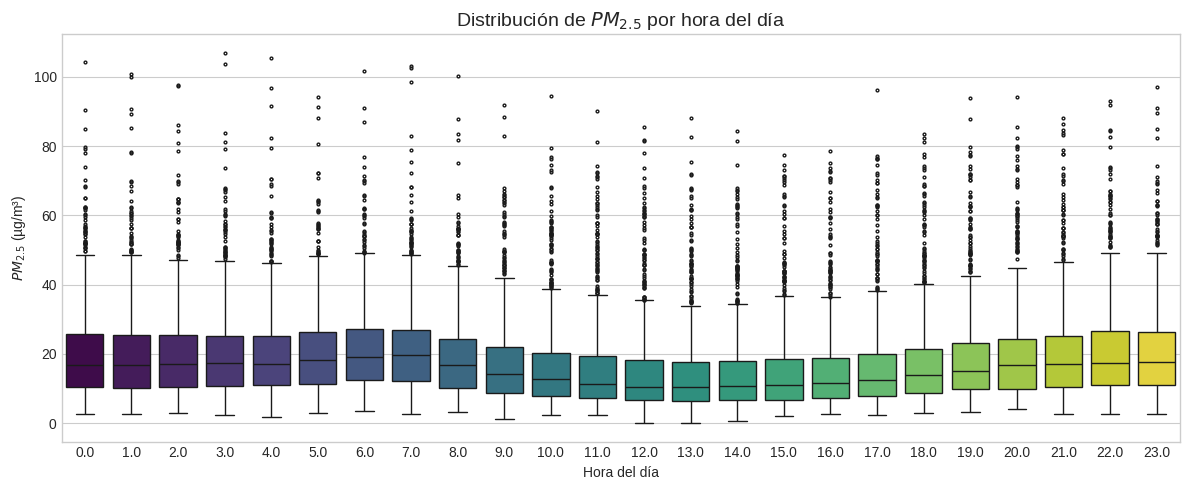

In [ ]:
# Distribution of PM2.5 by hour of the day

df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce', dayfirst=True)

# Convert the 'est_santa_cruz_gir_n_pm2_5' column to numeric, coercing errors to NaN
df["est_santa_cruz_gir_n_pm2_5"] = pd.to_numeric(df["est_santa_cruz_gir_n_pm2_5"], errors='coerce')

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df,
    x=df["tiempo"].dt.hour,
    y="est_santa_cruz_gir_n_pm2_5",
    hue=df["tiempo"].dt.hour,
    palette="viridis",
    fliersize=2
)

plt.legend([],[], frameon=False)
plt.title("Distribution of $PM_{2.5}$ by hour of the day", fontsize=14)
plt.xlabel("Hour of the day")
plt.ylabel("$PM_{2.5}$ (µg/m³)")
plt.tight_layout()
plt.show()

<div align = "justify">

The box plots show that there are certain hours of the day when $PM_{2.5}$ concentration is considerably higher. This behavior is consistent with what was observed in the humidity charts, since during the early morning hours and at night humidity tends to be higher, which favors the accumulation of particulate matter in the air. Conversely, in the afternoon, when solar radiation is more intense, there is a decrease in $PM_{2.5}$ concentrations. This is consistent with previous analyses, which showed that higher solar radiation contributes to reducing $PM_{2.5}$ concentration by increasing atmospheric mixing and particle dispersion.

</div>

# **4. Feature Engineering Methodological Approach**

<div align = "justify">

In this section, the process of building predictor variables (feature engineering) was carried out, in order to prepare the data from the *Santa Cruz – Girón Norte* station for use in supervised learning models.  

The procedure follows a temporal and causal logic, ensuring that there is no information leakage between past and future observations:

1. **Column filtering:**  
   Only the variables corresponding to the station of interest are selected, together with the `tiempo` column, reducing the dataset to the information strictly necessary for modeling.

2. **Temporal conversion and chronological ordering:**  
   The `tiempo` variable is transformed into `datetime` format and the records are sorted in ascending order to preserve the temporal sequence of the data.

3. **Target and lag generation:**  
   - The target variable `pm25_t+1` represents the future concentration of $PM_{2.5}$ (one hour ahead).  
   - Lag variables are created (`pm25_lag1`, `pm25_lag2`, `pm25_lag3`, and their equivalents for $PM_{10}$) that capture the temporal dependence of past concentrations.  
   This approach allows the model to learn dynamic patterns characteristic of environmental time series.

4. **Temporal encoding:**  
   Variables derived from the date (`hour`, `dayofweek`, `month`) and their trigonometric transformations (`sin`, `cos`) are added to represent hourly and weekly cycles continuously, improving the model's ability to capture periodicities.

5. **Final cleanup:**  
   The `NaN` values generated by the shifts (`shift`) are removed, leaving a fully numeric and ordered dataset, ready for training the prediction models.

This feature engineering pipeline forms the basis for the predictive analysis of $PM_{2.5}$, ensuring temporal consistency and an adequate representation of atmospheric variations.


</div>

In [ ]:
df.head()

,tiempo,est_santa_cruz_gir_n_pm10,est_santa_cruz_gir_n_pm2_5,est_santa_cruz_gir_n,est_santa_cruz_gir_n_lluvia,est_santa_cruz_gir_n_humedad,est_santa_cruz_gir_n_dir,est_santa_cruz_gir_n_vel,est_santa_cruz_gir_n_rad,pm25_t+1,...,pm10_lag2,pm25_lag3,pm10_lag3,hour,hour_sin,hour_cos,dayofweek,dow_sin,dow_cos,month
0,2018-10-01 04:00:00,15.1,5.7,22.3,0,87.8,340.1,0.8,0.0,9.5,...,16.2,5.5,12.7,4,0.866025,5.000000e-01,0,0.0,1.0,10
1,2018-10-01 05:00:00,25.1,9.5,21.9,0,90.4,327.1,0.7,8.5,9.6,...,16.3,6.6,16.2,5,0.965926,2.588190e-01,0,0.0,1.0,10
2,2018-10-01 06:00:00,28.5,9.6,22.8,0,85.3,321.8,1.0,159.4,7.1,...,15.1,6.7,16.3,6,1.000000,6.123234e-17,0,0.0,1.0,10
3,2018-10-01 07:00:00,20.8,7.1,25.2,0,73.4,316.8,0.9,385.8,6.4,...,25.1,5.7,15.1,7,0.965926,-2.588190e-01,0,0.0,1.0,10
4,2018-10-01 09:00:00,18.5,6.1,29.8,0,51.1,353.9,0.6,738.8,7.7,...,20.8,9.6,28.5,9,0.707107,-7.071068e-01,0,0.0,1.0,10


<div align = "justify">

It can be observed that after this processing, an initial dataset ready to be used in the modeling phase was obtained, with 12826 records, 23 features, and one output variable.

</div>

# **Train/Test Split**

<div align = "justify">

At this stage, the set of predictor variables was defined using only continuous numerical variables and temporal transformations (lags and cyclical encodings). The available categorical variables (such as station identifiers or cardinal directions in text format) are excluded because they would contribute little real variability to the model
and would require additional encoding schemes (one-hot) that would increase the dimensionality
without a clear benefit at this initial stage.

</div>

In [ ]:
# 1) Define target and features
target = "pm25_t+1"
drop_cols = ["tiempo", target]
X = df.drop(columns=drop_cols)
y = df[target].astype(float)

# 2) Temporal split: 80% train, 20% test, preserving the order
n = len(df)
cut = int(n * 0.8)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

X.columns

Index(['est_santa_cruz_gir_n_pm10', 'est_santa_cruz_gir_n_pm2_5',
       'est_santa_cruz_gir_n', 'est_santa_cruz_gir_n_lluvia',
       'est_santa_cruz_gir_n_humedad', 'est_santa_cruz_gir_n_dir',
       'est_santa_cruz_gir_n_vel', 'est_santa_cruz_gir_n_rad', 'pm25_lag1',
       'pm10_lag1', 'pm25_lag2', 'pm10_lag2', 'pm25_lag3', 'pm10_lag3', 'hour',
       'hour_sin', 'hour_cos', 'dayofweek', 'dow_sin', 'dow_cos', 'month'],
      dtype='object')

## **Outlier Detection**

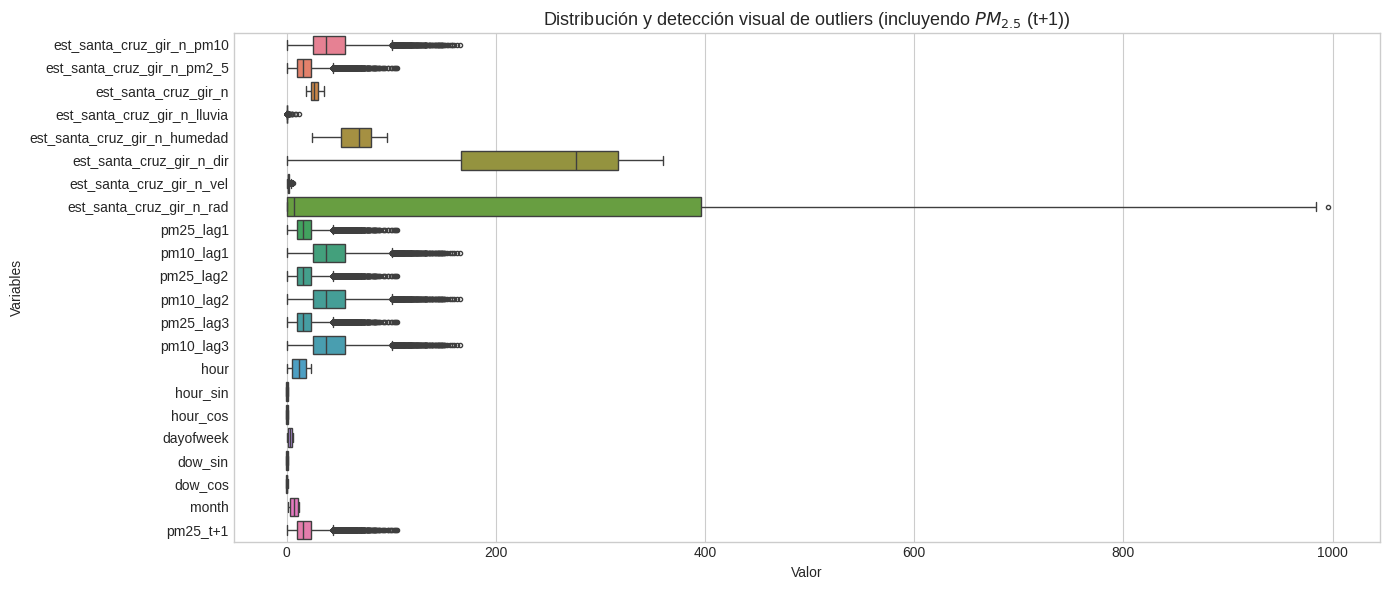

In [ ]:
# Join the features with the output variable
df_box = X_train.copy()
df_box["pm25_t+1"] = y_train.values

# Plot including the output
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_box, orient="h", fliersize=3, linewidth=1)
plt.title("Distribution and visual detection of outliers (including $PM_{2.5}$ (t+1))", fontsize=13)
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


<div align = "justify">

The inspection using boxplots reveals the presence of significant outliers in several predictor variables, especially in solar radiation, wind speed, and atmospheric pollutants. These outliers reflect the high natural variability of environmental data, influenced by extreme weather phenomena or specific pollution events.  

At this initial modeling stage these values were not removed, since the main objective was to evaluate the model's overall performance on real data without biasing the original distribution. Additionally, tree-based algorithms such as *Random Forest* exhibit inherent robustness to extreme values, which allows the integrity of the information to be preserved and retains possible anomalous behavior patterns relevant to the predictive analysis.

</div>

## **Correlation Matrix**

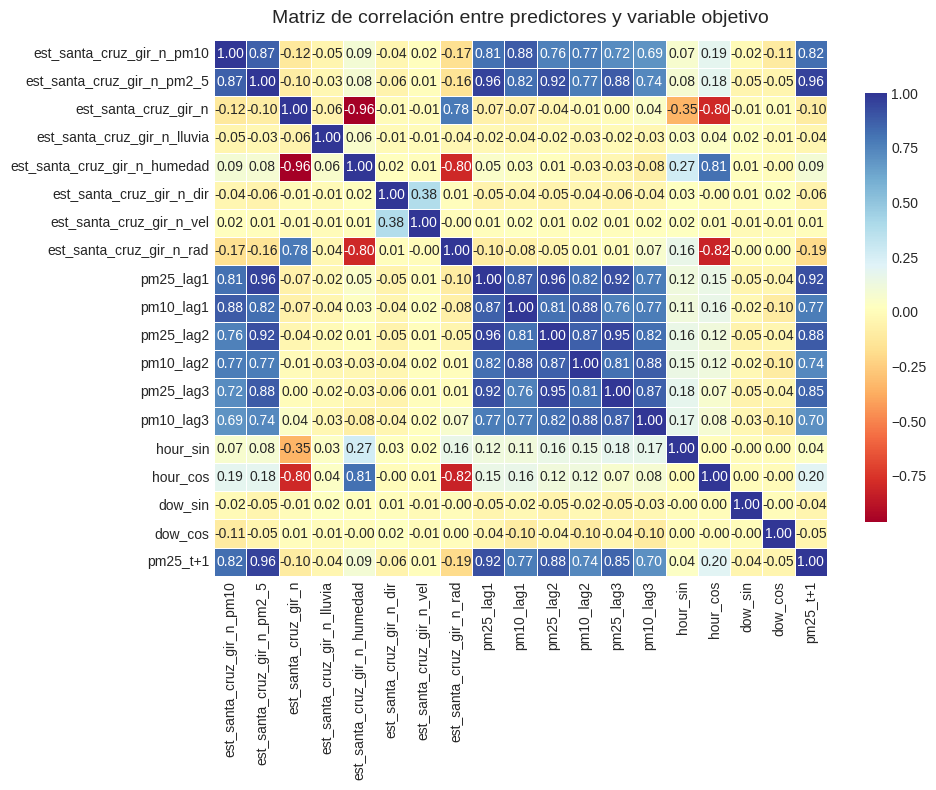

In [ ]:
df_corr = X_train.copy()
df_corr["pm25_t+1"] = y_train.values

numeric_cols = df_corr.select_dtypes(include=["float64", "int64"]).columns

corr_matrix = df_corr[numeric_cols].corr()


# Correlation matrix plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation matrix between predictors and target variable", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


<div align = "justify">

The correlation matrix reveals a strong linear relationship between $PM_{2.5}$ concentrations, both in their current values and in their temporal lags, with coefficients above 0.8. This confirms that past particulate matter concentrations are a good predictor of the future value of $PM_{2.5}$, which supports the choice of a time-series-based modeling approach.  

On the other hand, the meteorological variables show lower and more scattered correlations, which is expected given their stochastic and nonlinear nature. Nevertheless, they will be kept in the model, as they could provide relevant information for the generalization and stability of the predictive system.  

Accordingly, it was decided to keep all available variables, prioritizing the construction of a comprehensive model that captures both the temporal dependence and the environmental conditions.

</div>

# **5. Modeling Phase**

<div align = "justify">

In this phase, three supervised learning techniques were explored to estimate hourly $PM_{2.5} (t+1)$ concentrations. The goal was to evaluate their predictive performance using the available environmental and temporal variables, and to compare their results through a temporal validation scheme. This comparison allows for identifying the model with the best generalization capability for the Santa Cruz – Girón Norte station.

</div>

## **Random Forest**

<div align = "justify">

A basic *Random Forest Regressor* model was first implemented as an initial approach to supervised learning, using the processed dataset for the *Santa Cruz – Girón Norte* station. The goal was to quickly assess its predictive capability for hourly $PM_{2.5}$ concentrations, comparing performance metrics between the training and validation sets without hyperparameter tuning.

</div>

In [ ]:
# 1) Model definition
rf = RandomForestRegressor(
    n_estimators=200,   # number of trees
    random_state=42,
    n_jobs=-1)

# 2) Training
rf.fit(X_train, y_train)

# 3) Prediction
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

In [ ]:
# 4) Metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train)**(0.5)
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test)**(0.5)
r2_test = r2_score(y_test, y_pred_test)

print("Random Forest train results:")
print(f"RMSE: {rmse_train:.3f}")
print(f"MAE : {mae_train:.3f}")
print(f"R²  : {r2_train:.3f}")
print("Random Forest test results:")
print(f"RMSE: {rmse_test:.3f}")
print(f"MAE : {mae_test:.3f}")
print(f"R²  : {r2_test:.3f}")

Resultados Random Forest train:
RMSE: 1.422
MAE : 0.835
R²  : 0.989
Resultados Random Forest test:
RMSE: 3.716
MAE : 2.213
R²  : 0.960


<div align = "justify">

The implemented model shows a high level of performance according to the metrics used, which highlights the robustness of the methodological approach applied and underscores the potential of this dataset for use in machine learning projects aimed at promoting environmental care and protection.

</div>

## **Adaptive Boosting (AdaBoost)**

<div align = "justify">

As a second approach, the AdaBoost algorithm was used, a boosting-based ensemble method that combines multiple weak models (in this case, shallow trees) to progressively improve predictive capability. AdaBoost iteratively adjusts the errors of the previous model, making it possible to capture nonlinear relationships and complex variability in hourly $PM_{2.5}$ concentrations.

</div>

In [ ]:
# Base model: small tree
base_estimator = DecisionTreeRegressor(max_depth=3)

# Create the AdaBoost model
ada_model = AdaBoostRegressor(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42)

# Train the model
ada_model.fit(X_train, y_train)

# Prediction
y_pred_2 = ada_model.predict(X_test)
y_pred_test_2 = ada_model.predict(X_test)

In [ ]:
rmse_train_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_train_2 = mean_absolute_error(y_test, y_pred_2)
r2_train_2 = r2_score(y_test, y_pred_2)

rmse_test_2 = np.sqrt(mean_squared_error(y_test, y_pred_test_2))
mae_test_2 = mean_absolute_error(y_test, y_pred_test_2)
r2_test_2 = r2_score(y_test, y_pred_test_2)

print("AdaBoost train results:")
print(f"RMSE: {rmse_train_2:.3f}")
print(f"MAE : {mae_train_2:.3f}")
print(f"R²  : {r2_train_2:.3f}")
print("AdaBoost test results:")
print(f"RMSE: {rmse_test_2:.3f}")
print(f"MAE : {mae_test_2:.3f}")
print(f"R²  : {r2_test_2:.3f}")

Resultados AdaBoost train:
RMSE: 4.701
MAE : 3.277
R²  : 0.936
Resultados AdaBoost test:
RMSE: 4.701
MAE : 3.277
R²  : 0.936


<div align = "justify">

The AdaBoost model showed consistent performance in both training and testing, with similar RMSE, MAE, and R² values. This suggests that the algorithm generalizes properly and shows no clear signs of overfitting. However, although the results are solid, its performance remains slightly below that obtained with Random Forest, indicating that AdaBoost captures the structure of the problem but with less capacity to explain the total variability of $PM_{2.5} (t+1)$.

</div>

## **Ridge Regression with $L_{2}$ Regularization**

<div align = "justify">

As a third approach, Ridge Regression was used, a regularized linear model that incorporates an $L_2$ term to penalize large coefficients and reduce overfitting. This type of model is useful for assessing the capacity of a regularized linear relationship to capture the hourly dynamics of $PM_{2.5}$, serving as a point of comparison with respect to the ensemble methods previously tested.

</div>

In [ ]:
# Create the Ridge model
ridge_model = Ridge(
    alpha=1.0,
    random_state=42)

# Train the model
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_train_3 = ridge_model.predict(X_test)
y_pred_test_3 = ada_model.predict(X_test)

In [ ]:
rmse_train_2 = np.sqrt(mean_squared_error(y_test, y_pred_train_3))
mae_train_2 = mean_absolute_error(y_test, y_pred_test_3)
r2_train_2 = r2_score(y_test, y_pred_test_3)

rmse_test_2 = np.sqrt(mean_squared_error(y_test, y_pred_test_3))
mae_test_2 = mean_absolute_error(y_test, y_pred_test_3)
r2_test_2 = r2_score(y_test, y_pred_test_3)

print("Ridge Regression train results:")
print(f"RMSE: {rmse_train_2:.3f}")
print(f"MAE : {mae_train_2:.3f}")
print(f"R²  : {r2_train_2:.3f}")
print("Ridge Regression test results:")
print(f"RMSE: {rmse_test_2:.3f}")
print(f"MAE : {mae_test_2:.3f}")
print(f"R²  : {r2_test_2:.3f}")

Resultados Ridge Regression train:
RMSE: 3.621
MAE : 3.277
R²  : 0.936
Resultados Ridge Regression test:
RMSE: 4.701
MAE : 3.277
R²  : 0.936


<div align = "justify">

Comparing the results with AdaBoost, Ridge Regression shows a lower error on the training set (RMSE = 3.621 versus 4.701), indicating a more efficient fit under a strictly linear relationship. However, on the test set both models converge to the same level of performance (RMSE = 4.701, MAE = 3.277, and R² = 0.936), which suggests that Ridge's actual predictive capability does not exceed that of boosting. This confirms that AdaBoost does not exploit additional patterns during the training phase and that, in this case, both methods offer equivalent generalization, although Ridge remains conceptually simpler and more efficient.

</div>

## **Complexity Analysis**

<div align = "justify">

In addition to evaluating predictive performance, the computational complexity of the selected models was analyzed. This analysis considers training and prediction times as a practical indicator of the efficiency of each technique, which is especially relevant for software deployment applications, where the speed of forecast generation is a key factor.

</div>

### **Random Forest**

In [ ]:
start_train = time.time()
rf.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
rf.predict(X_test)
end_pred = time.time()

print("\n--- RANDOM FOREST COMPLEXITY ---")
print(f"Training time:   {end_train - start_train:.4f} s")
print(f"Prediction time: {end_pred - start_pred:.4f} s")


--- COMPLEJIDAD RANDOM FOREST ---
Tiempo entrenamiento: 33.5556 s
Tiempo predicción:    0.1548 s


<div align = "justify">

The Random Forest model showed a considerably high training time, due to the number of trees and the parallelizable nature of the algorithm. However, the prediction time was very fast, which is advantageous for a real-time forecasting system. In general, the computational cost of training is high, but inference is highly efficient.

</div>

### **ADA Boost**

In [ ]:
start_train = time.time()
ada_model.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
ada_model.predict(X_test)
end_pred = time.time()

print("\n--- ADABOOST COMPLEXITY ---")
print(f"Training time:   {end_train - start_train:.4f} s")
print(f"Prediction time: {end_pred - start_pred:.4f} s")


--- COMPLEJIDAD ADA BOOST ---
Tiempo entrenamiento: 8.0908 s
Tiempo predicción:    0.0849 s


<div align = "justify">

Compared with Random Forest, AdaBoost showed a significantly lower training time, while also maintaining a very short prediction time. This reflects greater computational efficiency during model fitting, although its predictive performance did not reach that of Random Forest. Even so, AdaBoost offers an attractive balance between training cost and fast inference.

</div>

### **Ridge Regression**

In [ ]:
start_train = time.time()
ridge_model.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
ridge_model.predict(X_test)
end_pred = time.time()

print("\n--- RIDGE REGRESSION COMPLEXITY ---")
print(f"Training time:   {end_train - start_train:.6f} s")
print(f"Prediction time: {end_pred - start_pred:.6f} s")


--- COMPLEJIDAD RIDGE REGRESSION ---
Tiempo entrenamiento: 0.009441 s
Tiempo predicción:    0.002251 s


<div align = "justify">

Ridge Regression showed the lowest computational cost among the evaluated models, with training and prediction times that were practically instantaneous. This is due to the closed-form nature of its solution and the absence of complex iterative processes. Although its predictive capability is lower than that of Random Forest and AdaBoost, its computational efficiency makes it an extremely lightweight option, suitable as a baseline reference or for scenarios where speed takes priority over precision.

</div>

## **Model Export**

<div align = "justify">

Once the best-performing model was identified, it was exported together with the list of columns used during training. This packaging ensures that the application uses exactly the same features during the inference phase. The resulting file (`best_rf_pm25.pkl`) was subsequently incorporated into the development of the desktop graphical interface called AirAMB, where the model is used to generate operational $PM_{2.5} (t+1)$ predictions.

</div>

In [ ]:
# Package model + column names
bundle = {
    "model": rf,
    "feature_cols": X_train.columns.tolist()
}

# Save to disk
joblib.dump(bundle, "best_rf_pm25.pkl")

print("Model saved as best_rf_pm25.pkl")

Modelo guardado como best_rf_pm25.pkl


## **Prediction Validation**

<div align = "justify">

In order to evaluate the model's behavior in specific situations, ten instants from the test set were randomly selected and the predictions generated by Random Forest were compared with the observed real values of $PM_{2.5}(t+1)$. This point-by-point validation made it possible to individually review absolute and relative errors, identify possible patterns of overestimation or underestimation, and verify the model's consistency against real cases. Additionally, summary metrics (MAE, RMSE, and average bias) were calculated to obtain an additional measure of performance outside the training environment.

</div>

In [ ]:
#Point-by-point validation with real cases from the test set

# Number of examples we want to review "by hand"
n_muestras = 10

# We select random indices, but only from the test set (y_test)
idx_mini = y_test.sample(n=n_muestras, random_state=42).index

# Subset of X_test and y_test corresponding to those indices
X_mini = X_test.loc[idx_mini]
y_real_mini = y_test.loc[idx_mini]

# Random Forest predictions for those cases
y_pred_mini = rf.predict(X_mini)

# Building the evaluation DataFrame
mini_df = pd.DataFrame({
    "pm25_t+1_real": y_real_mini,
    "pm25_t+1_pred": y_pred_mini
}, index=idx_mini)

# Error computation
mini_df["error_abs"] = (mini_df["pm25_t+1_real"] - mini_df["pm25_t+1_pred"]).abs()
mini_df["error_%"] = 100 * mini_df["error_abs"] / mini_df["pm25_t+1_real"].replace(0, np.nan)

# If the original DataFrame has a time column, it is added as context
if "tiempo" in df.columns:
    mini_df["tiempo"] = df.loc[idx_mini, "tiempo"]

# Summary metrics for this mini-validation
mae_mini = mini_df["error_abs"].mean()
rmse_mini = np.sqrt(((mini_df["pm25_t+1_real"] - mini_df["pm25_t+1_pred"])**2).mean())
bias_mini = (mini_df["pm25_t+1_pred"] - mini_df["pm25_t+1_real"]).mean()

print(f"AirAMB mini-validation on the test set (n = {len(mini_df)})")
print(f"  MAE  = {mae_mini:.2f} µg/m³")
print(f"  RMSE = {rmse_mini:.2f} µg/m³")
print(f"  Bias = {bias_mini:.2f} µg/m³")

# Sorted by time
cols_orden = ["tiempo", "pm25_t+1_real", "pm25_t+1_pred", "error_abs", "error_%"]
cols_orden = [c for c in cols_orden if c in mini_df.columns]

display(mini_df[cols_orden].sort_values(by=cols_orden[0]))


Mini-validación AirAMB sobre el conjunto de prueba (n = 10)
  MAE  = 1.39 µg/m³
  RMSE = 1.72 µg/m³
  Bias = -0.07 µg/m³


,tiempo,pm25_t+1_real,pm25_t+1_pred,error_abs,error_%
10438,2020-02-17 02:00:00,15.1,15.8770,0.7770,5.145695
11212,2020-05-20 08:00:00,7.1,7.6650,0.5650,7.957746
11233,2020-05-21 05:00:00,15.9,16.7255,0.8255,5.191824
11541,2020-06-03 01:00:00,14.6,10.9430,3.6570,25.047945
11680,2020-06-08 20:00:00,9.7,6.6530,3.0470,31.412371
11929,2020-06-19 05:00:00,7.0,8.0395,1.0395,14.850000
12162,2020-06-28 22:00:00,5.6,6.4890,0.8890,15.875000
12186,2020-06-29 22:00:00,6.2,7.6645,1.4645,23.620968
12340,2020-07-06 08:00:00,9.8,10.8480,1.0480,10.693878
12790,2020-07-25 02:00:00,10.9,10.3415,0.5585,5.123853


<div align = "justify">

The `evaluar_instante` function was defined, which makes it possible to analyze the performance of the Random Forest model at a specific date and time in the station's history. Based on the entered timestamp, the function retrieves the corresponding record, computes the $PM_{2.5} (t+1)$ prediction, and compares it with the observed value, reporting the absolute and relative error. Additionally, it prints all the input variables used ($PM_{2.5}$ and $PM_{10}$ with their lags, temporal variables, and meteorological variables), which makes it easier to exactly replicate that case within the AirAMB desktop application and cross-validate the predictions between the notebook and the graphical interface.

</div>

In [ ]:
def evaluar_instante(fecha_hora_str):
    """
    Evaluates the performance of the Random Forest model for a given instant t,
    comparing the PM2.5(t+1) prediction with the observed real value, as well as the features used.

    Parameters
    ----------
    fecha_hora_str : str
        Date and time in the format: "YYYY-MM-DD HH:MM:SS"
    """

    # ================
    # COLUMN MAPPING
    # ================

    # PM2.5 and its lags
    col_pm25_t  = "est_santa_cruz_gir_n_pm2_5"  # PM2.5 at t
    col_pm25_l1 = "pm25_lag1"                   # PM2.5 (t-1)
    col_pm25_l2 = "pm25_lag2"                   # PM2.5 (t-2)
    col_pm25_l3 = "pm25_lag3"                   # PM2.5 (t-3)

    # PM10 and its lags
    col_pm10_t  = "est_santa_cruz_gir_n_pm10"   # PM10 at t
    col_pm10_l1 = "pm10_lag1"                   # PM10 (t-1)
    col_pm10_l2 = "pm10_lag2"                   # PM10 (t-2)
    col_pm10_l3 = "pm10_lag3"                   # PM10 (t-3)

    # Temporal variables
    col_hour  = "hour"
    col_dow   = "dayofweek"
    col_month = "month"

    # Meteorological variables
    col_precip  = "est_santa_cruz_gir_n_lluvia"    # mm
    col_rad     = "est_santa_cruz_gir_n_rad"       # W/m²
    col_viento  = "est_santa_cruz_gir_n_vel"       # m/s
    col_dir_v   = "est_santa_cruz_gir_n_dir"       # degrees
    col_humedad = "est_santa_cruz_gir_n_humedad"   # %
    col_temp    = "est_santa_cruz_gir_n"           # adjust if a specific T column exists

    # Helper to format numeric values even if they come as strings
    def fmt_val(value):
        v = pd.to_numeric(value, errors="coerce")
        if pd.isna(v):
            return "NaN"
        return f"{v:.2f}"

    # 1) Check for the time column
    if "tiempo" not in df.columns:
        print("The df DataFrame does not have a 'tiempo' column.")
        return

    # 2) Convert the date
    fecha_hora = pd.to_datetime(fecha_hora_str)

    # 3) Locate the row corresponding to t
    fila_t = df.loc[df["tiempo"] == fecha_hora]
    if fila_t.empty:
        print("That date/time was not found in df['tiempo'].")
        return

    idx = fila_t.index[0]

    # 4) Extract the EXACT feature vector used by the model
    X_row = X.loc[[idx]]

    # 5) Actual value at t+1
    y_real_t1 = float(df.loc[idx, "pm25_t+1"])

    # 6) Model prediction
    y_pred_t1 = float(rf.predict(X_row)[0])

    # 7) Errors
    error_abs = abs(y_real_t1 - y_pred_t1)
    error_pct = 100 * error_abs / y_real_t1 if y_real_t1 != 0 else np.nan

    # 8) Performance results
    print("===== AirAMB point evaluation =====")
    print(f"Date/time t:            {df.loc[idx, 'tiempo']}")
    print(f"PM₂.₅(t+1) actual:      {y_real_t1:.2f} µg/m³")
    print(f"PM₂.₅(t+1) predicted:   {y_pred_t1:.2f} µg/m³")
    print(f"Absolute error:         {error_abs:.2f} µg/m³")
    print(f"Relative error:         {error_pct:.1f} %")

    # 9) Features for the interface
    print("\n===== Features to enter in the AirAMB interface =====")

    # --- PM2.5 ---
    print("\nPM₂.₅ concentrations (µg/m³)")
    print(f"PM₂.₅(t)    : {fmt_val(df.loc[idx, col_pm25_t])}")
    print(f"PM₂.₅(t-1)  : {fmt_val(df.loc[idx, col_pm25_l1])}")
    print(f"PM₂.₅(t-2)  : {fmt_val(df.loc[idx, col_pm25_l2])}")
    print(f"PM₂.₅(t-3)  : {fmt_val(df.loc[idx, col_pm25_l3])}")

    # --- PM10 ---
    print("\nPM₁₀ concentrations (µg/m³)")
    print(f"PM₁₀(t)     : {fmt_val(df.loc[idx, col_pm10_t])}")
    print(f"PM₁₀(t-1)   : {fmt_val(df.loc[idx, col_pm10_l1])}")
    print(f"PM₁₀(t-2)   : {fmt_val(df.loc[idx, col_pm10_l2])}")
    print(f"PM₁₀(t-3)   : {fmt_val(df.loc[idx, col_pm10_l3])}")

    # --- Temporal variables ---
    print("\nTemporal variables")
    print(f"Hour of day (0–23)    : {int(df.loc[idx, col_hour])}")
    print(f"Day of week (0–6)     : {int(df.loc[idx, col_dow])}")
    print(f"Month (1–12)          : {int(df.loc[idx, col_month])}")

    # --- Meteorological variables ---
    print("\nMeteorological variables")
    print(f"Precipitation (mm)         : {fmt_val(df.loc[idx, col_precip])}")
    print(f"Solar radiation (W/m²)     : {fmt_val(df.loc[idx, col_rad])}")
    print(f"Wind speed (m/s)           : {fmt_val(df.loc[idx, col_viento])}")
    print(f"Wind direction (°)         : {fmt_val(df.loc[idx, col_dir_v])}")
    print(f"Relative humidity (%)      : {fmt_val(df.loc[idx, col_humedad])}")
    if col_temp in df.columns:
        print(f"Ambient temperature (°C)   : {fmt_val(df.loc[idx, col_temp])}")

In [ ]:
evaluar_instante("2020-02-17 02:00:00")

===== Evaluación puntual AirAMB =====
Fecha/hora t:          2020-02-17 02:00:00
PM₂.₅(t+1) real:       15.10 µg/m³
PM₂.₅(t+1) predicho:   15.88 µg/m³
Error absoluto:        0.78 µg/m³
Error relativo:        5.1 %

===== Features para ingresar en la interfaz de AirAMB =====

Concentraciones PM₂.₅ (µg/m³)
PM₂.₅(t)    : 16.70
PM₂.₅(t-1)  : 14.40
PM₂.₅(t-2)  : 18.80
PM₂.₅(t-3)  : 20.50

Concentraciones PM₁₀ (µg/m³)
PM₁₀(t)     : 27.50
PM₁₀(t-1)   : 26.40
PM₁₀(t-2)   : 33.50
PM₁₀(t-3)   : 37.20

Variables temporales
Hora del día (0–23)   : 2
Día de la semana (0–6): 0
Mes (1–12)            : 2

Variables meteorológicas
Precipitación (mm)        : 0.00
Radiación solar (W/m²)    : 0.00
Velocidad del viento (m/s): 2.40
Dirección del viento (°)  : 328.40
Humedad relativa (%)      : 62.90
Temperatura ambiente (°C) : 25.50


<div align = "justify">

> Add blockquote



The output obtained reflects a rigorous methodological approach, which makes it possible to validate the results obtained in the graphical interface.

</div>

## **Results Analysis**

<div align = "justify">

The following table summarizes the error metrics, explanatory power, and computation times of the three models evaluated. This comparison makes it possible to identify not only which one offers the best predictive performance, but also how it behaves in terms of computational efficiency during training and prediction.

<div align = "center">

| Model                 | RMSE Train | MAE Train |  R² Train | RMSE Test |  MAE Test |   R² Test | Training Time (s) | Prediction Time (s) |
|:--------------------:|:---------:|:--------:|:--------:| :--------:|:--------:|:--------:|:-----------------------:| :--------------------:|
| **Ridge Regression** |      3.621 |     3.277 |     0.936 |     4.701 |     3.277 |     0.936 |               **0.0094** |           **0.00225** |
| **AdaBoost**         |      4.701 |     3.277 |     0.936 |     4.701 |     3.277 |     0.936 |                   8.0908 |                0.0849 |
| **Random Forest**    |  **1.422** | **0.835** | **0.989** | **3.716** | **2.213** | **0.960** |                  33.5556 |                0.1548 |

**Table 1.** Results analysis.

</div>

On the other hand, the following figure illustrates different typical time-complexity curves for machine learning algorithms. Comparing them with the metrics table above makes it possible to contextualize the training and prediction times observed for each model.

<div style="text-align: center;">
    <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*oX6upkyuk51fUh7NQ16WCg.jpeg"
         alt="Big O complexity"
         width="600">

  **Source:** Medium (2022)
</div>

</div>

<div align = "justify">

- **Ridge Regression – Complexity O(n · p²)**

For Ridge, complexity mainly depends on two things:

* n, the number of data points,

* p, the number of variables or columns used to train the model.

Ridge works directly with matrices that include all the features, which is why p significantly affects the time. As more variables are added (for example, more lags, more meteorological columns, etc.), the model becomes somewhat more costly. Even so, Ridge remains very fast.

This is reflected in the results: its training time was practically instantaneous (0.009 s). This means that, even if the dataset grows, Ridge can handle it well and does not become heavy. The same applies to the prediction time, which is also very low.

Overall, Ridge is ideal when speed is needed, although being linear, it does not capture complex relationships the way other models do.

- **AdaBoost – Complexity O(n · m)**

For AdaBoost, complexity depends on:

n: the number of data points,

m: the number of weak learners (trees) the model builds.

Here, the number of variables p does not matter as much, because AdaBoost uses small trees that do not analyze all the data at once the way Ridge does. What matters most is m, because the more trees the model has, the more times it must go over the data to adjust the weights and correct the errors.

This is evident in the results: training AdaBoost took approximately 8 seconds, which is much more than Ridge, but not excessive either. This makes sense because m = 200 trees were used here, which already implies a considerable amount of repeated work.

The impact of m is also seen in prediction: it is not as fast as Ridge's (0.084 s), because to predict a single point AdaBoost must sum the output of all the trees.

In summary, AdaBoost is more costly due to the number of trees, but in exchange it improves the model's ability to capture nonlinear patterns.

- **Random Forest – Complexity O(n · m · log n)**

Random Forest is the most complex of the three because its training depends on three things:

n: number of data points,

m: number of trees in the forest,

log n: which comes from the internal logic of the trees when splitting the data at each node.

Each tree in the forest performs many splits to find the best cut points, and these splits grow according to log n. Additionally, since m = 200 trees are used, this process is repeated many times.

This explains why Random Forest took the longest to train (33.55 s), clearly being the heaviest of the models tested. Its prediction also takes more time (0.154 s), since it must query all the trees before producing the final result.

Despite being the slowest, it is also the one with the best performance in the metrics. This makes sense because Random Forest handles complex and noisy relationships, such as those present in $PM_{2.5}$ data, very well.

</div>

## **Conclusions**

<div align="justify">

The exploratory analysis made it possible to identify marked patterns in the behavior of $PM_{2.5}$ both throughout the year and within the daily cycle. A significant increase in the pollutant was observed during the first months of the year and during the early morning hours, a phenomenon consistent with atmospheric conditions typical of that period: lower solar radiation, high humidity, and limited vertical mixing, factors that favor the accumulation of fine particulate matter.

The Santa Cruz – Girón Norte station was selected as the basis for modeling because it presented the greatest completeness and consistency in its records. This data availability made it possible to train the models with greater stability, reducing the uncertainty associated with gaps or inconsistencies and producing more robust results compared to the other stations evaluated.

The analysis confirmed that the recent dynamics of $PM_{2.5}$ have a decisive influence on its future evolution. The incorporated lags showed a strong relationship with the value to be predicted, evidencing the autocorrelated nature of the pollutant. Likewise, the cyclical encoding of the temporal variables made it possible to more adequately capture the daily and weekly cycles, avoiding artificial breaks between consecutive hours or days.

Among the techniques evaluated, tree-based models — especially Random Forest — showed the best performance, which is consistent with their ability to handle nonlinear relationships, interactions between variables, and the presence of noise. In contrast, linear models such as Ridge Regression showed limitations inherent to their structure when facing more complex patterns in the environmental data.

The temporal validation strategy, in which training is performed on an initial period and testing on later observations, was essential for obtaining realistic results. This methodology avoided information leakage from the future into training and made it possible to evaluate the model's ability to predict unseen conditions, faithfully reproducing the operational use of the system.

Although the results were satisfactory, there is room for improving forecast accuracy. Incorporating advanced models such as LSTM, more rigorous outlier removal, or the integration of higher-resolution satellite and meteorological data could strengthen predictive capability, especially in scenarios where air quality changes more rapidly.

Overall, the project demonstrates that machine learning techniques are a useful tool for the operational prediction of $PM_{2.5}$ in Bucaramanga. The adopted approach makes it possible to anticipate increases in the pollutant and provides valuable support for air quality management and the formulation of preventive strategies.

</div>

## **References**

- Franco Pineda, D. A. (2020). Análisis y caracterización del material particulado PM10 y PM2.5 en la ciudad de Manizales. Universidad Nacional de Colombia. https://bffrepositorio.unal.edu.co/server/api/core/bitstreams/4d9ceee1-5e9d-4adb-b476-d5b6192f9f76/content.

- Yu, R., Yang, Y., Yang, L., Han, G., & Move, O.A. (2016). RAQ: A Random Forest Approach for Predicting Air Quality in Urban Sensing Systems. Sensors, 16(1), 86.

- Yi, X., Zhang, J., Wang, Z., Li, T., & Zheng, Y. (2018). Deep Distributed Fusion Network for Air Quality Prediction. ACM SIGKDD Conference on Knowledge Discovery and Data Mining.

- Veljanovska, K., & Dimoski, A. (2018). Air Quality Index Prediction Using Simple Machine Learning Algorithms. International Journal of Emerging Trends in Technology and Computer Science, 7, 25–30.

- WHO (2024). Air pollution. Health topics. https://www.unep.org/es/explore-topics/air/about-aire

- Raimondo, G., Montuori, A., Moniaci, W., Pasero, E., & Almkvist, E. (2007). A Machine Learning Tool to Forecast PM10 Level. Proceedings of the Fifth Conference on Artificial Intelligence Applications to Environmental Science (AMS), San Antonio, TX.

- Scikit-Learn Documentation. (2024). RandomForestRegressor. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

- Baladram, S. (2024). Decision Tree Regressor, Explained: A Visual Guide with Code Examples – Trimming branches smartly with Cost-Complexity Pruning. Towards Data Science. https://towardsdatascience.com/decision-tree-regressor-explained-a-visual-guide-with-code-examples-fbd2836c3bef/


- Baladram, S. (2024). AdaBoost Classifier, Explained: A Visual Guide with Code Examples – Putting the weight where weak learners need it most. Medium. https://medium.com/data-science/adaboost-classifier-explained-a-visual-guide-with-code-examples-fc0f25326d7b

- Medium. (2022). Explicación de la notación Big O: aprenda a analizar el rendimiento del código. https://medium.com/@diego.coder/notaci%C3%B3n-big-o-615bd1e0a227

- Área Metropolitana de Bucaramanga. (2024). Reporte Calidad de Aire AMB [Data set]. Datos Abiertos Colombia. https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Reporte-Calidad-de-Aire-AMB/58ct-h586/about_data

